In [1]:
import cv2
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
import numpy as np  

In [2]:
image_path="/Users/berkantastan/Documents/GitHub/FootballAnalysis-Yolo/output_videos/cropped_player_2.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

Text(0.5, 1.0, 'player')

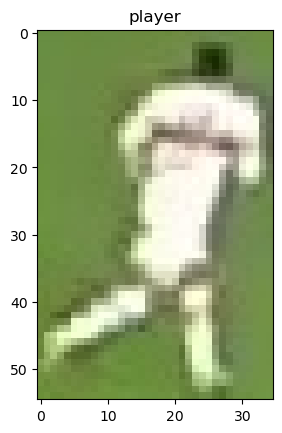

In [3]:
plt.imshow(image)
plt.title("player")

In [4]:
height, width, _ = image.shape

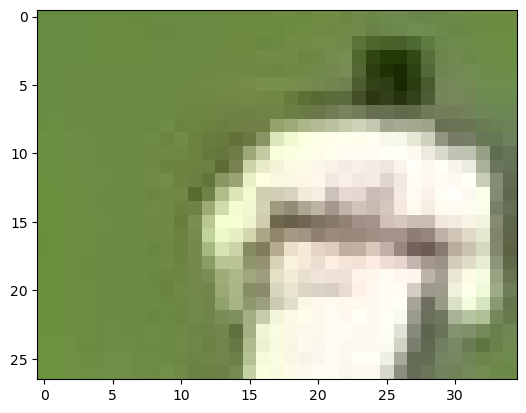

In [5]:
top_image = image[0:int(height/2), 0:width]
plt.imshow(top_image)

In [6]:
image_2d = top_image.reshape(-1, 3)
print(image_2d.shape)

(945, 3)


In [7]:
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

KMeans(n_clusters=2, random_state=0)

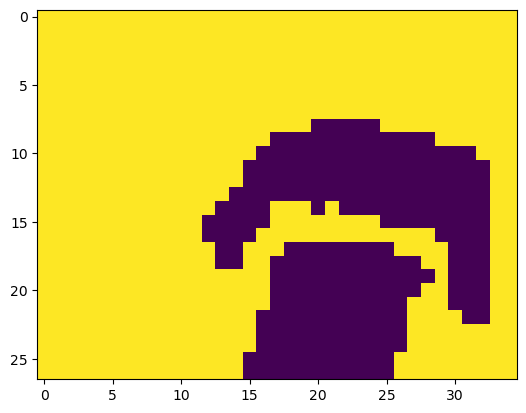

In [8]:
labels = kmeans.labels_
image_kmeans = labels.reshape((top_image.shape[0], top_image.shape[1]))
plt.imshow(image_kmeans)

In [9]:
corner_clusters = [image_kmeans[0, 0], image_kmeans[0, -1], image_kmeans[-1, 0], image_kmeans[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print("Non-player cluster:", non_player_cluster)

Non-player cluster: 1


In [10]:
player_cluster = 1 - non_player_cluster
print("Player cluster:", player_cluster)

Player cluster: 0


In [11]:
kmeans.cluster_centers_[player_cluster ]

array([235.16205534, 232.40711462, 213.88537549])